###SVR

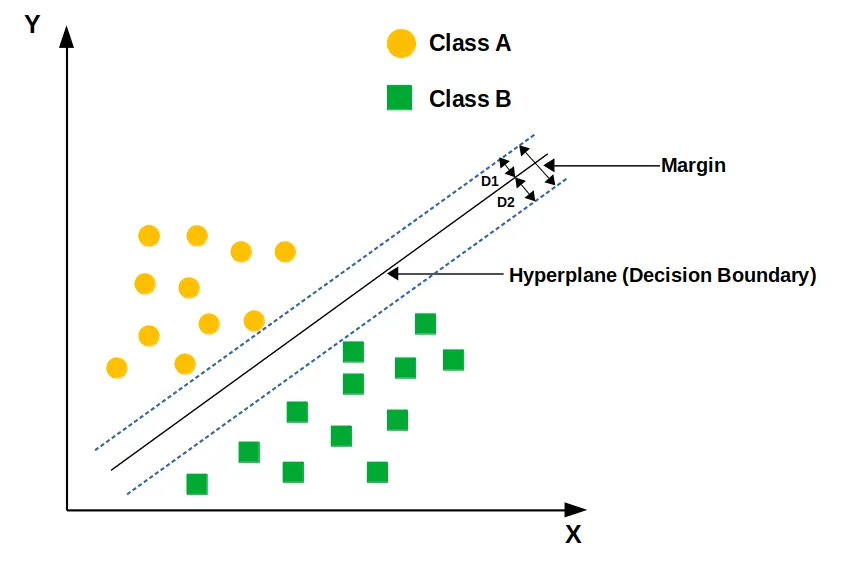

In [1]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
dataset = load_breast_cancer ()
X = dataset.data
y = dataset.target

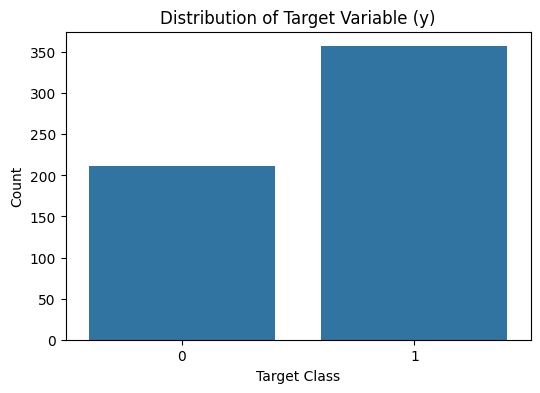

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

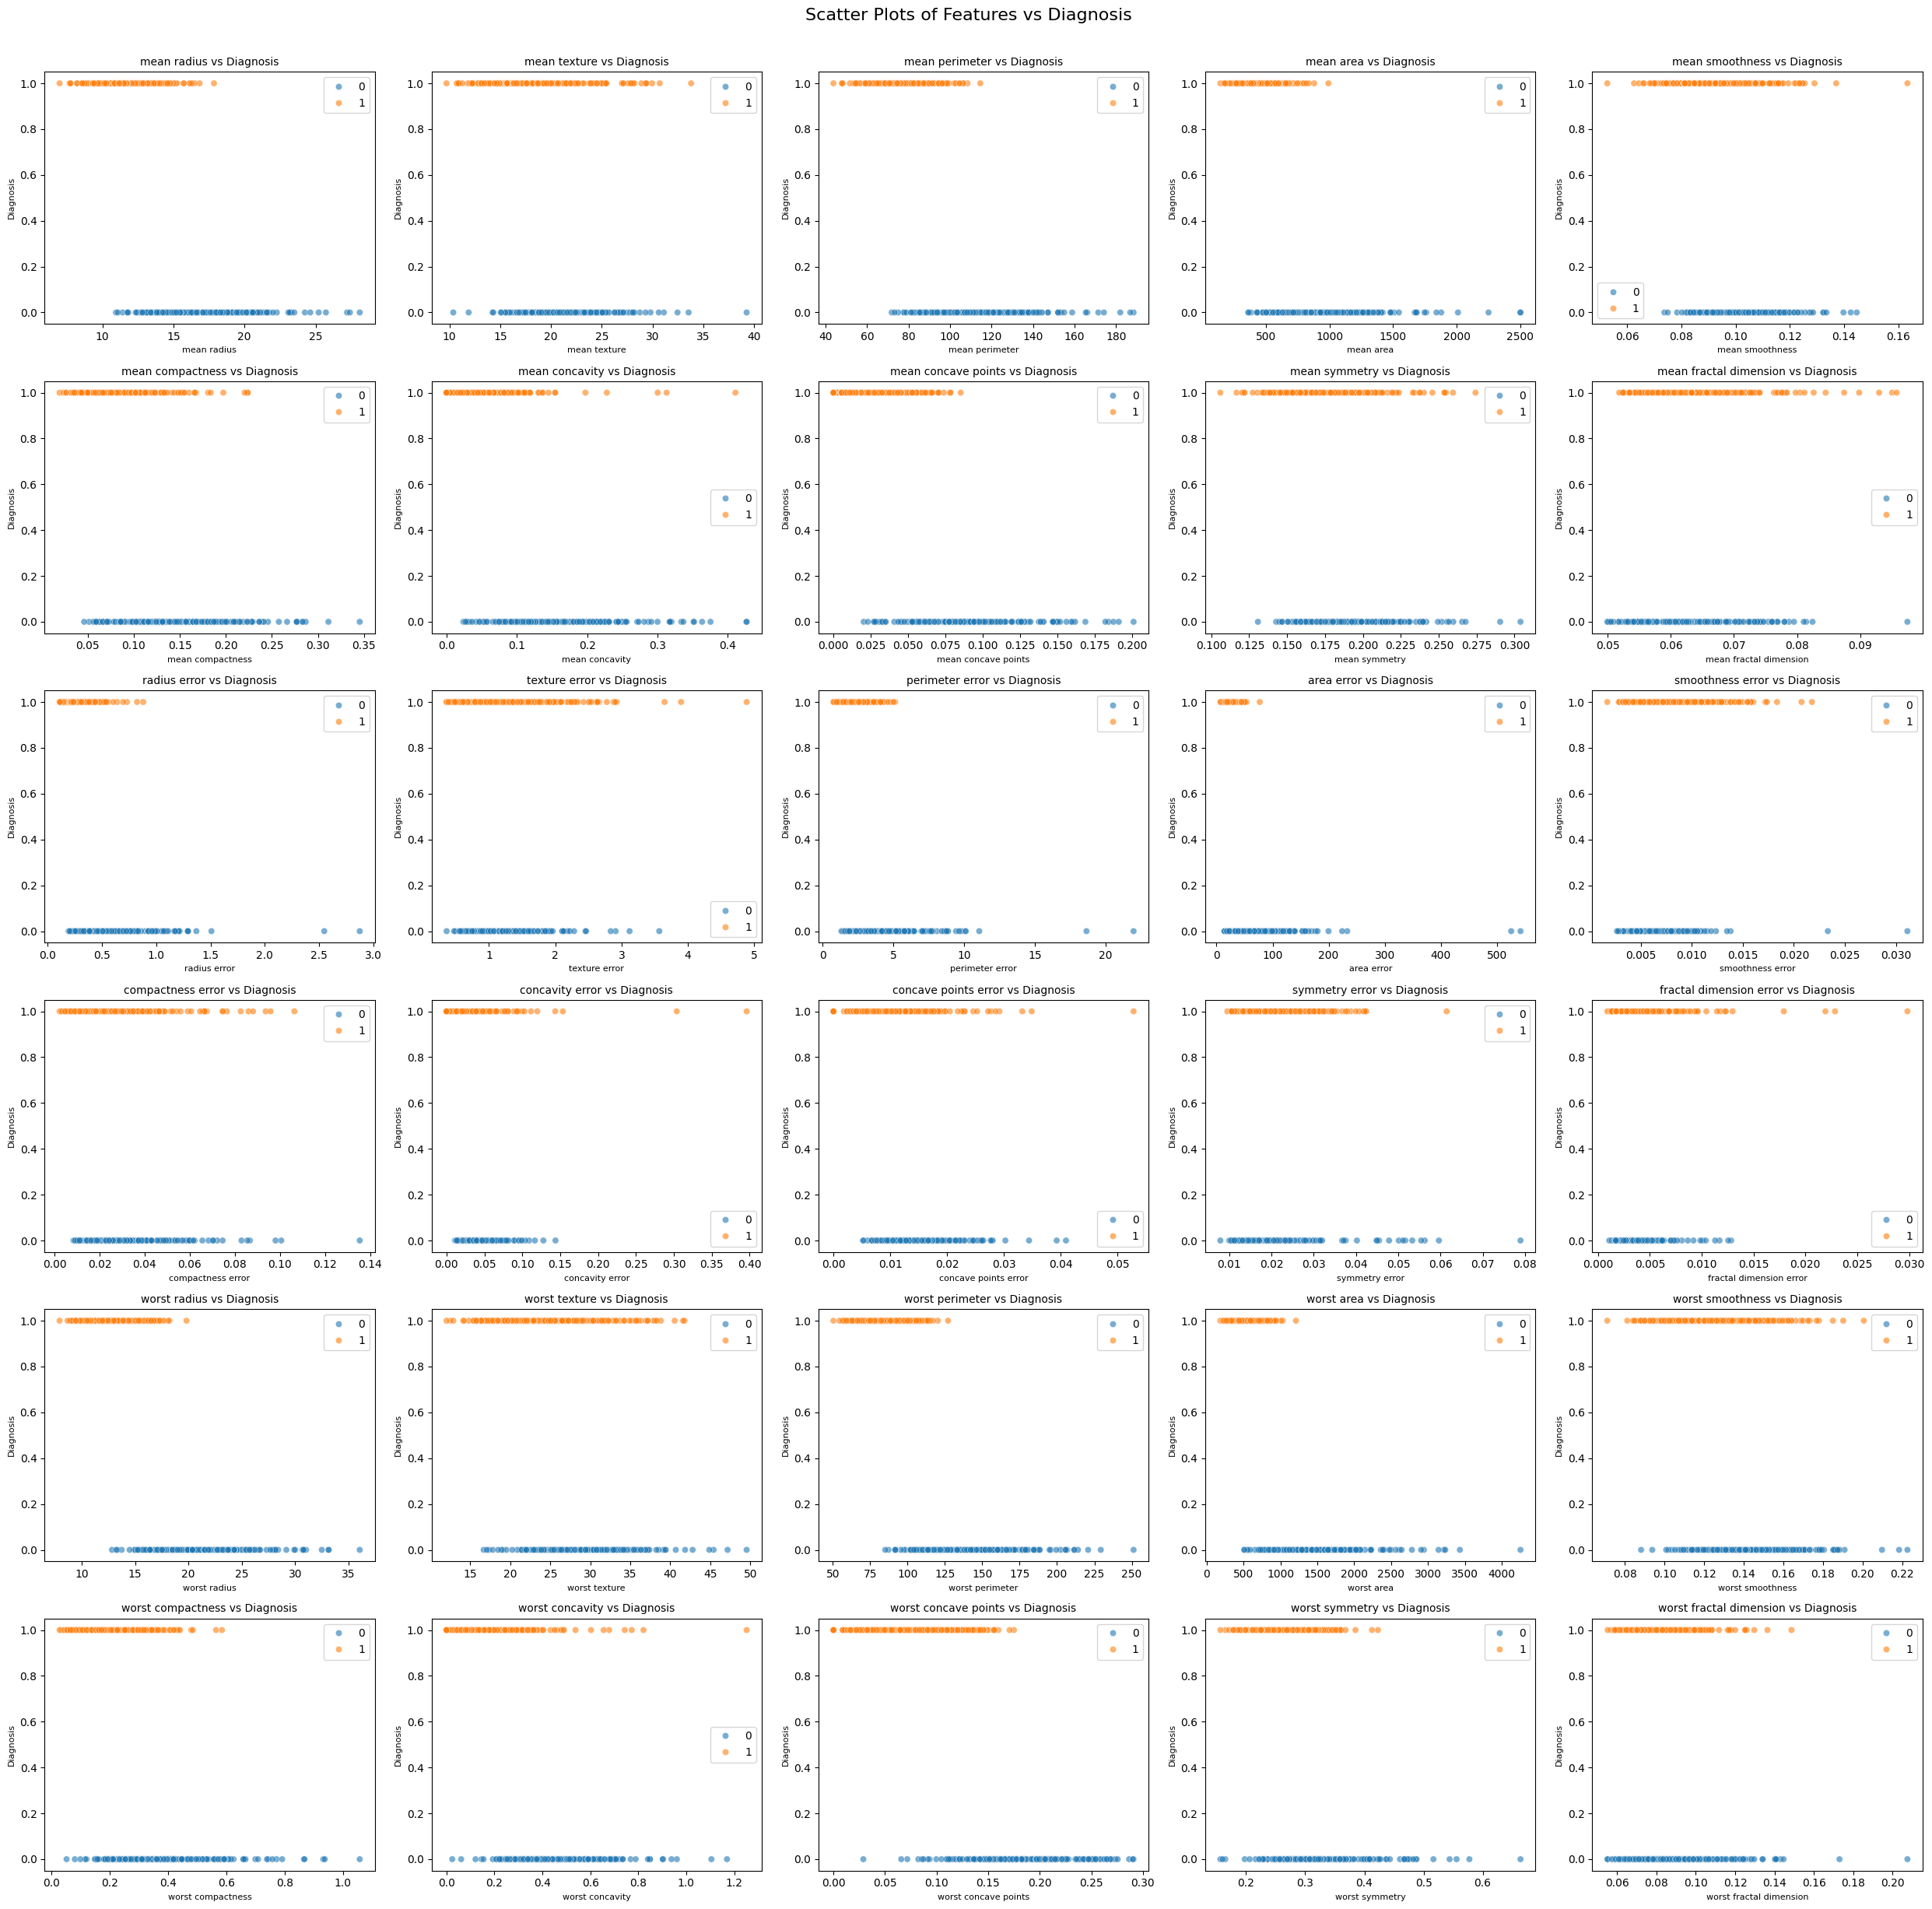

In [5]:
# Assuming dataset, X, and y are already defined from previous cells

# Get feature names from the 'X' DataFrame (which contains features, excluding the target)
feature_names = dataset.feature_names.tolist()
n_features = len(feature_names)

# Determine grid size for subplots (e.g., 5 columns)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, feature_name in enumerate(feature_names):
    sns.scatterplot(x=X[:, i], y=y, hue=y, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{feature_name} vs Diagnosis', fontsize=10)
    axes[i].set_xlabel(feature_name, fontsize=8)
    axes[i].set_ylabel('Diagnosis', fontsize=8)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Scatter Plots of Features vs Diagnosis', y=1.02, fontsize=16)
plt.show()

In [7]:
import numpy as np

print(f"Data type of X:\n{X.dtype}")
print(f"Is X numerical? {np.issubdtype(X.dtype, np.number)}")
print(f"Data type of y: {y.dtype}")
print(f"Is y fully numerical? {np.issubdtype(y.dtype, np.number)}")

Data type of X:
float64
Is X numerical? True
Data type of y: int64
Is y fully numerical? True


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.33,
                                                    random_state=44,
                                                    shuffle=True)

In [9]:
print("Null values in X:", np.isnan(X).sum())
print("Null values in y:", np.isnan(y).sum())

Null values in X: 0
Null values in y: 0


In [12]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the training features (X_train)
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to the test features (X_test)
X_test_scaled = scaler.transform(X_test)


In [18]:
SVCmodel = SVC(kernel='rbf', max_iter=1000, C=0.1, gamma='auto')
SVCmodel.fit(X_train_scaled,y_train)

SVCmodel2 = SVC(kernel='linear', max_iter=1000, C=0.1, gamma='auto')
SVCmodel2.fit(X_train_scaled,y_train)

SVC(C=0.1, gamma='auto', kernel='linear', max_iter=1000)

In [20]:
print("rbf kernel")
print(SVCmodel.score(X_train_scaled, y_train))
print(SVCmodel.score(X_test_scaled, y_test))

print("linear kernel")
print(SVCmodel2.score(X_train_scaled, y_train))
print(SVCmodel2.score(X_test_scaled, y_test))

rbf kernel
0.9606299212598425
0.925531914893617
linear kernel
0.984251968503937
0.9627659574468085


In [22]:
from sklearn.metrics import classification_report

print("Classification Report for RBF Kernel (Training Set):")
print(classification_report(y_train, SVCmodel.predict(X_train_scaled)))

print("Classification Report for RBF Kernel (Test Set):")
print(classification_report(y_test, SVCmodel.predict(X_test_scaled)))

print("Classification Report for Linear Kernel (Training Set):")
print(classification_report(y_train, SVCmodel2.predict(X_train_scaled)))

print("Classification Report for Linear Kernel (Test Set):")
print(classification_report(y_test, SVCmodel2.predict(X_test_scaled)))

Classification Report for RBF Kernel (Training Set):
              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95       144
         1.0       0.95      0.99      0.97       237

    accuracy                           0.96       381
   macro avg       0.96      0.95      0.96       381
weighted avg       0.96      0.96      0.96       381

Classification Report for RBF Kernel (Test Set):
              precision    recall  f1-score   support

         0.0       0.88      0.93      0.90        68
         1.0       0.96      0.93      0.94       120

    accuracy                           0.93       188
   macro avg       0.92      0.93      0.92       188
weighted avg       0.93      0.93      0.93       188

Classification Report for Linear Kernel (Training Set):
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       144
         1.0       0.98      1.00      0.99       237

    accuracy            

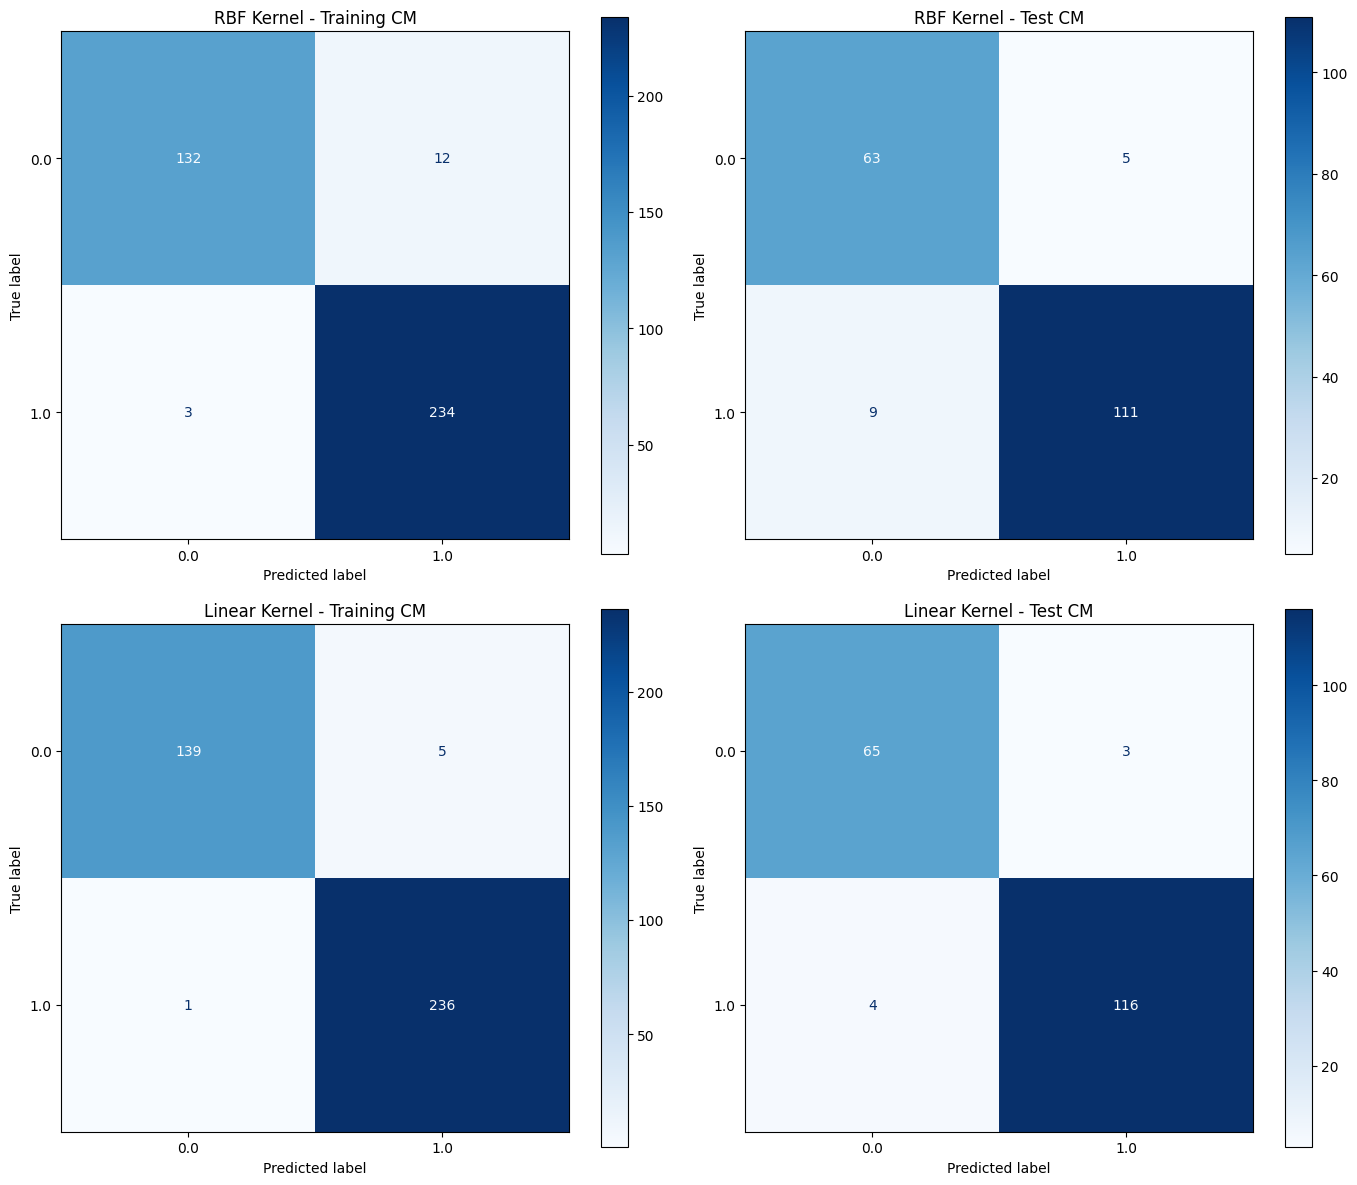

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# RBF Kernel - Training Data
ConfusionMatrixDisplay.from_estimator(
    SVCmodel, X_train_scaled, y_train, cmap=plt.cm.Blues, ax=axes[0, 0]
)
axes[0, 0].set_title('RBF Kernel - Training CM')

# RBF Kernel - Test Data
ConfusionMatrixDisplay.from_estimator(
    SVCmodel, X_test_scaled, y_test, cmap=plt.cm.Blues, ax=axes[0, 1]
)
axes[0, 1].set_title('RBF Kernel - Test CM')

# Linear Kernel - Training Data
ConfusionMatrixDisplay.from_estimator(
    SVCmodel2, X_train_scaled, y_train, cmap=plt.cm.Blues, ax=axes[1, 0]
)
axes[1, 0].set_title('Linear Kernel - Training CM')

# Linear Kernel - Test Data
ConfusionMatrixDisplay.from_estimator(
    SVCmodel2, X_test_scaled, y_test, cmap=plt.cm.Blues, ax=axes[1, 1]
)
axes[1, 1].set_title('Linear Kernel - Test CM')

plt.tight_layout()
plt.show()

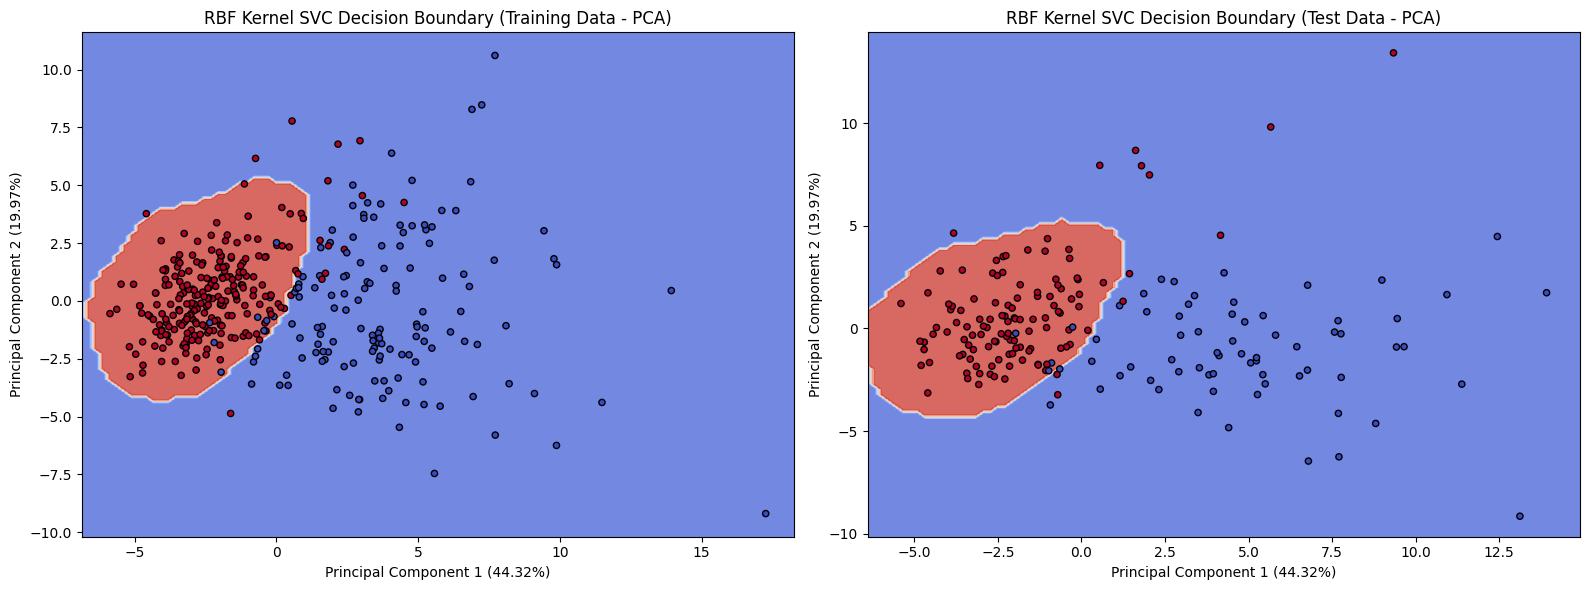

In [23]:
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

# Reduce dimensions to 2 for visualization using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a new SVC model on the 2-component PCA data
svc_pca_rbf = SVC(kernel='rbf', max_iter=1000, C=0.1, gamma='auto')
svc_pca_rbf.fit(X_train_pca, y_train)

# Create a figure with two subplots for training and test decision boundaries
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot decision boundary for training data
disp_train = DecisionBoundaryDisplay.from_estimator(
    svc_pca_rbf, X_train_pca, response_method="predict", cmap=plt.cm.coolwarm, alpha=0.8, ax=ax1,
    xlabel=f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)",
    ylabel=f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)"
)
disp_train.ax_.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
disp_train.ax_.set_title('RBF Kernel SVC Decision Boundary (Training Data - PCA)')

# Plot decision boundary for test data
disp_test = DecisionBoundaryDisplay.from_estimator(
    svc_pca_rbf, X_test_pca, response_method="predict", cmap=plt.cm.coolwarm, alpha=0.8, ax=ax2,
    xlabel=f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)",
    ylabel=f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)"
)
disp_test.ax_.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
disp_test.ax_.set_title('RBF Kernel SVC Decision Boundary (Test Data - PCA)')

plt.tight_layout()
plt.show()

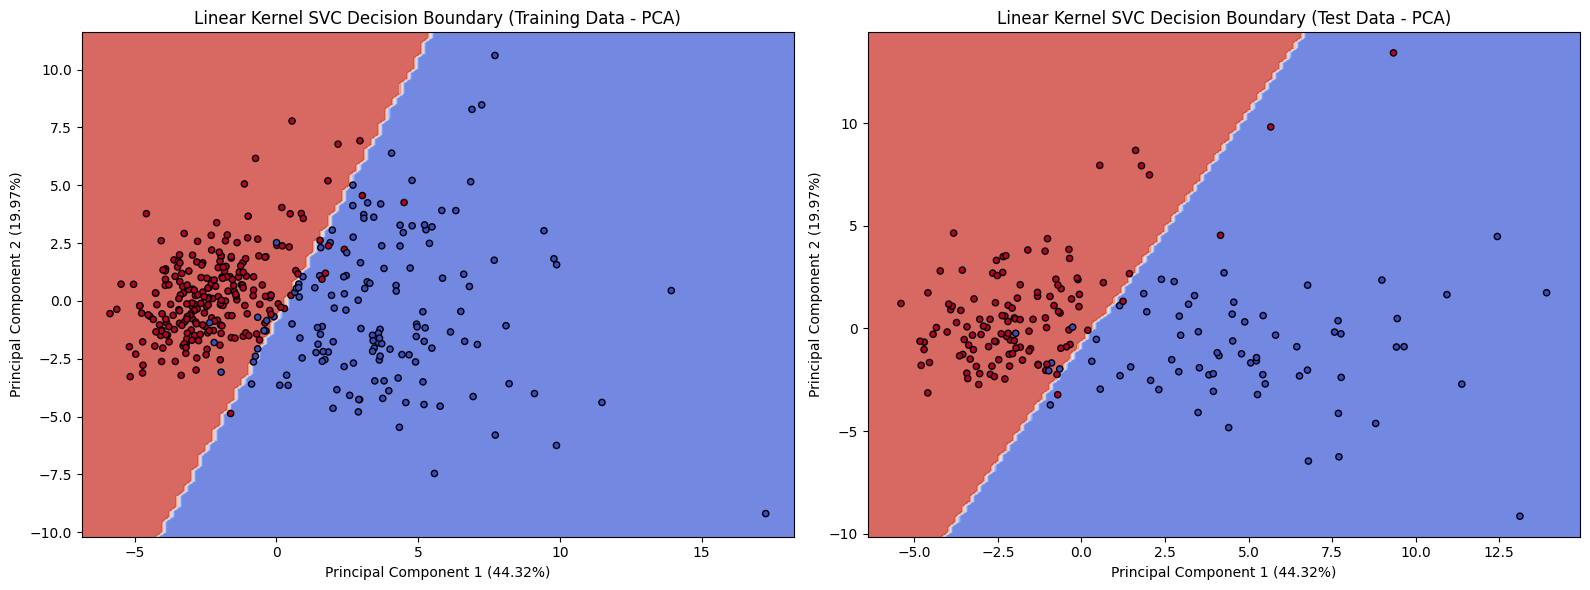

In [24]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC

# Train a new SVC model with a linear kernel on the 2-component PCA data
svc_pca_linear = SVC(kernel='linear', max_iter=1000, C=0.1, gamma='auto')
svc_pca_linear.fit(X_train_pca, y_train)

# Create a figure with two subplots for training and test decision boundaries
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot decision boundary for training data
disp_train_linear = DecisionBoundaryDisplay.from_estimator(
    svc_pca_linear, X_train_pca, response_method="predict", cmap=plt.cm.coolwarm, alpha=0.8, ax=ax1,
    xlabel=f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)",
    ylabel=f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)"
)
disp_train_linear.ax_.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
disp_train_linear.ax_.set_title('Linear Kernel SVC Decision Boundary (Training Data - PCA)')

# Plot decision boundary for test data
disp_test_linear = DecisionBoundaryDisplay.from_estimator(
    svc_pca_linear, X_test_pca, response_method="predict", cmap=plt.cm.coolwarm, alpha=0.8, ax=ax2,
    xlabel=f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)",
    ylabel=f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)"
)
disp_test_linear.ax_.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
disp_test_linear.ax_.set_title('Linear Kernel SVC Decision Boundary (Test Data - PCA)')

plt.tight_layout()
plt.show()